# Recitation Week 5: Image Processing

Today we will learn how an image becomes a NumPy array. We will look at RGB channels, resize, change brightness, and rotate an image.

**Teaching time:** 32 minutes, then 3 minutes for quiz instructions, then 20 minutes for the Lab 1 Skills Quiz.

## 1. Load and inspect an image (5 minutes)

Put `dog.png` in the same folder as this notebook.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

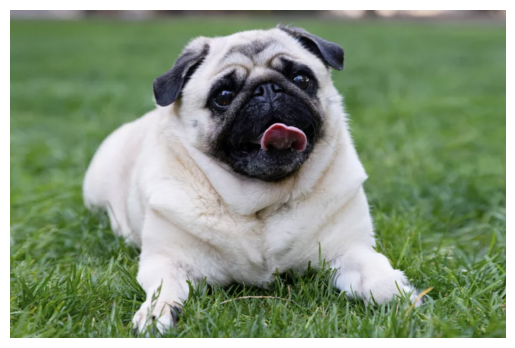

Shape: (1034, 1562, 3)
First pixel: [142 139 150]


In [2]:
img = Image.open("dog.png").convert("RGB")
img_array = np.array(img)

plt.imshow(img)
plt.axis("off")
plt.show()

print("Shape:", img_array.shape)
print("First pixel:", img_array[0, 0])

**Say:** The shape is `(height, width, channels)`. The three numbers in one pixel are red, green, and blue. Each value is from 0 to 255. We only print one pixel because the full array is very large.

## 2. RGB channels and slicing (8 minutes)

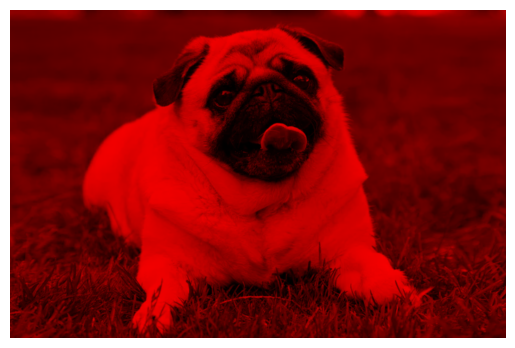

In [3]:
red_only = np.zeros_like(img_array)
red_only[:, :, 0] = img_array[:, :, 0]

plt.imshow(red_only)
plt.axis("off")
plt.show()

**Say:** `:` means every row and every column. The last index `0` means the red channel. We start with zeros, so green and blue stay zero. Use index `1` for green and `2` for blue. We keep all three channels so Matplotlib can show real RGB colors.

## 3. Resize and predict the shape (4 minutes)

New shape: (200, 300, 3)


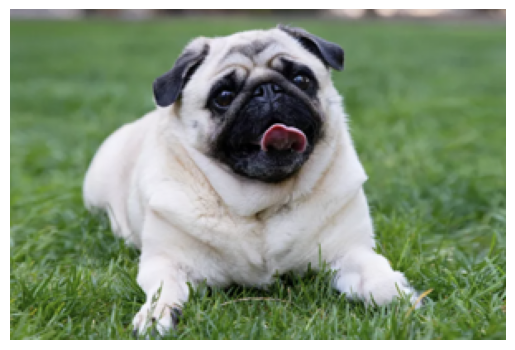

In [4]:
resized_img = img.resize((300, 200))
resized_array = np.array(resized_img)

print("New shape:", resized_array.shape)
plt.imshow(resized_img)
plt.axis("off")
plt.show()

**Ask before running:** What will the new shape be?

**Answer:** `(200, 300, 3)`. Pillow uses `(width, height)`, but NumPy shows `(height, width, channels)`. Forcing a new width and height may stretch the image.

## 4. Dim and brighten (5 minutes)

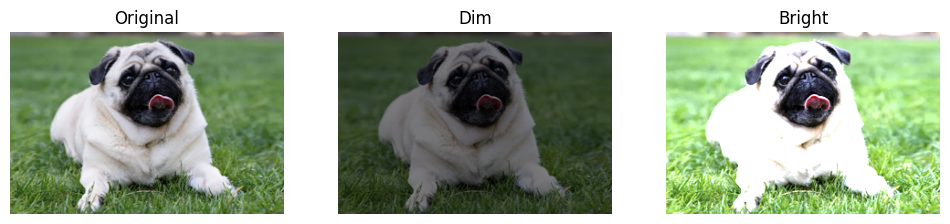

In [5]:
rgb = resized_array / 255.0
dim = 0.5 * rgb
bright = np.clip(1.7 * rgb, 0, 1)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, picture, title in zip(
    axes, [rgb, dim, bright], ["Original", "Dim", "Bright"]
):
    ax.imshow(picture)
    ax.set_title(title)
    ax.axis("off")
plt.show()

**Say:** Dividing by 255 changes the values to the range 0 to 1. Multiplying by 0.5 makes the image darker. Multiplying by 1.7 makes it brighter. `np.clip` keeps every value between 0 and 1. For example, `0.8 * 1.7 = 1.36`, so it becomes `1.0`.

## 5. Rotate 90 degrees counterclockwise (4 minutes)

Before rotation: (200, 300, 3)
After rotation: (300, 200, 3)


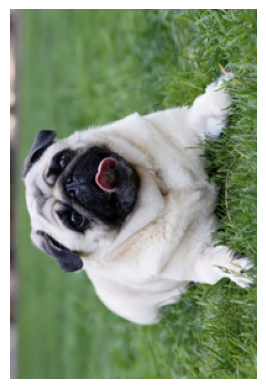

In [6]:
rotated = np.rot90(rgb)

print("Before rotation:", rgb.shape)
print("After rotation:", rotated.shape)
plt.imshow(rotated)
plt.axis("off")
plt.show()

**Ask before running:** If the shape is `(200, 300, 3)`, what is the rotated shape?

**Answer:** `(300, 200, 3)`. The height and width switch. Use `np.rot90` for rotation. A transpose by itself reflects the image across a diagonal; it is not the same operation.

## 6. Group practice (6 minutes)

Work in groups of 2 or 3. You have 4 minutes to code and 2 minutes to review.

Starting with `dog.png`:

1. Convert it to RGB.
2. Resize it to width 300 and height 200.
3. Convert the pixel values to floats from 0 to 1.
4. Make a red-only image.
5. Make it half as bright.
6. Rotate it 90 degrees counterclockwise.
7. Display it and print its shape.

Before running, predict: Which channels will be zero? What will the final shape be?

In [7]:
# Starter code: students complete the rest
practice_img = Image.open("dog.png").convert("RGB")
practice_img = practice_img.resize((300, 200))
practice_rgb = np.array(practice_img) / 255.0

# TODO: create a red-only image
# TODO: reduce brightness by half
# TODO: rotate 90 degrees counterclockwise
# TODO: display the result and print its shape

### Group practice solution

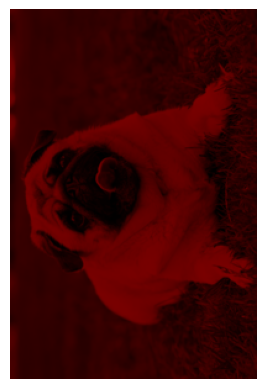

(300, 200, 3)


In [8]:
practice_red = np.zeros_like(practice_rgb)
practice_red[:, :, 0] = practice_rgb[:, :, 0]
dim_red = 0.5 * practice_red
practice_rotated = np.rot90(dim_red)

plt.imshow(practice_rotated)
plt.axis("off")
plt.show()
print(practice_rotated.shape)

**Review:** The output shape is `(300, 200, 3)`. Green and blue are zero. Red values are between 0 and 0.5. Ask one group to explain why `[:, :, 0]` selects the red channel.

## Quiz instructions (3 minutes)

1. Open the Lab 1 Skills Quiz Student Guide.
2. Go to `codepost.cs.rutgers.edu`.
3. Choose **Student** and select your current course.
4. Open **Quizzes** and find **Lab 1 Skills Quiz**.
5. The questions use your own Lab 1 code. Read each question and adapt your code to the new task.
6. Make sure you submit before time ends.

The quiz is based on Lab 1, not today's image-processing material. The final 20 minutes are reserved for the quiz.